# Introduction

This notebook walks throught the production of Fig. S04, the coherence between vorticity in the currents and the magnitude of the current-induced perturbation in the Stokes drift from the WW3-LVWD&CUR, WW3-NOREF, and WW3-NOCRT simulations. A confidence level is estimated form a chi-2 distribution considering a 1-week decorrelation scale (see `../analysis/decorrelation_scale.ipynb`).

## Imports

In [1]:
import sys
sys.path.append("../src")

In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from spec_plot import (
    plot_coherence,
)

plt.rcdefaults()
plt.style.use("../src/paper.mplstyle")

# Data

In [3]:
INPUT_DIR = Path('../data/coherence/')

In [4]:
coh_rot_us_lvwd_cur = xr.open_zarr(INPUT_DIR / 'vort_us_lvwd_cur.zarr', consolidated=False)
coh_rot_us_noref = xr.open_zarr(INPUT_DIR / 'vort_us_noref.zarr', consolidated=False)
coh_rot_us_nocrt = xr.open_zarr(INPUT_DIR / 'vort_us_nocrt.zarr', consolidated=False)

# Aside: Current-induced Perturbation

We are interested in the relationship between divergence in the currents and variability in the Stokes drift driven only by currents and **not** but wind. We therefore define the current-induced pertubation as
$$
\Delta U_{s, \text{ model}} = U_{s, \text{ model}} - U_{s, \text{ LVWD}}
$$
where $U_s$ is the magnitude of the Stokes drift and `model` indicates the model of interest (WW3-LVWD&CUR, WW3-NOREF, WW3-NOCRT). This has already been computed in `analysis/compute_coherence_divergence.py`.

# Plotting

Plotting is therefore quite straightforward.

In [9]:
fig08_styles = {
    r"$\zeta \rightarrow \Delta U_\mathrm{s, LVWD&CUR}$": {
        "ds": coh_rot_us_lvwd_cur,
        "color": "mediumseagreen",
        "linestyle": "--",
        "linewidth": 1.5,
    },
    r"$\zeta \rightarrow \Delta U_\mathrm{s, NOREF}$": {
        "ds": coh_rot_us_noref,
        "color": "darkblue",
        "linestyle": "-.",
        "linewidth": 1.5,
    },
    r"$\zeta \rightarrow \Delta U_\mathrm{s, NOCRT}$": {
        "ds": coh_rot_us_nocrt,
        "color": "royalblue",
        "linestyle": "-.",
        "linewidth": 1.5,
    },
}

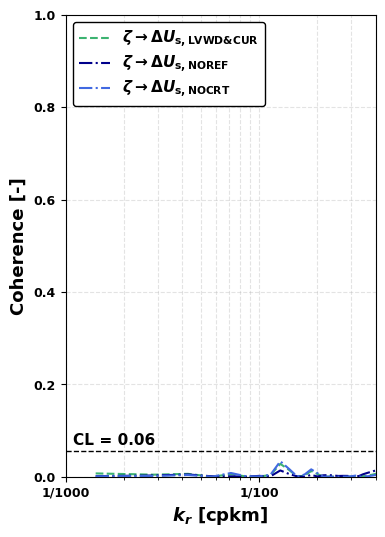

In [10]:
fig, ax = plot_coherence(
    fig08_styles,
    figsize=(4, 6),
    xlim=(1e-3, 1/25)
)

# ------------------------------------------------------------
# Add peak locations to both panels
# ------------------------------------------------------------
# for kr in div_peaks.kr.values:
#     ax.axvline(
#         kr,
#         color='black',
#         linestyle='--',
#         linewidth=0.8,
#         zorder=4,
#     )

#     # Label only on top panel
#     ax.text(
#         kr * 1.02,
#         0.76,
#         f"1/{1/kr:.0f} cpkm",
#         transform=ax.get_xaxis_transform(),
#         rotation=90,
#         ha='center',
#         va='top',
#         fontsize=10,
#         color='black',
#         bbox=dict(
#             facecolor='white',
#             edgecolor='none',
#             alpha=1.0,
#             pad=0.5
#         ),
#         zorder=5,
#     )

ax.legend(
        loc="upper left",
        frameon=True,
        framealpha=1.0,
        facecolor="white",
        edgecolor="black",
        labelspacing=0.25,
    )

plt.show()

In [11]:
fig.savefig(
    '../figures/figS04.png',
    dpi=500,
    bbox_inches='tight',
    pad_inches=0.1,
)